In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
import joblib

In [6]:
import pandas as pd

df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad Property Data.csv", encoding='ISO-8859-1')


In [7]:
df.drop(columns=['Unnamed: 8','Unnamed: 9','Unnamed: 10'],inplace=True)
df.dropna(how='all',inplace=True)


In [8]:
df

,Locality,Quarter,Price Range,Average Price,Q-o-Q,Growth Type,City,Type
54,Adibatla,Oct-Dec 2024,"2,938-4,880","3,909",4%,NaN,NaN,NaN
55,Adibatla,Jul-Sep 2024,"3,050-5,060","4,055",4%,NaN,NaN,NaN
56,Adibatla,Apr-Jun 2024,"2,794-5,004","3,899",6%,NaN,NaN,NaN
57,Adibatla,Jan-Mar 2024,"2,707-4,683","3,695",6%,NaN,NaN,NaN
58,Adibatla,Oct-Dec 2023,"2,922-4,921","3,922",2%,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
4643,Yousufguda Main Road,Jul-Sep 2019,"5,090-8,760","7,030",-,NaN,NaN,NaN
4644,Yousufguda Main Road,Apr-Jun 2019,"5,070-8,730","7,010",-,NaN,NaN,NaN
4645,Yousufguda Main Road,Jan-Mar 2019,"5,050-8,700","6,990",-,NaN,NaN,NaN
4646,Yousufguda Main Road,Oct-Dec 2018,"5,030-8,670","6,970",-,NaN,NaN,NaN


In [9]:
print("size of df : " , df.shape)
print("df type of each colum in the df : ",df.dtypes)
print("no of null values :", df.isnull().sum())
duplicate_values = df.duplicated().sum()
print("no of duplicated values",duplicate_values)
numerical_summary = df.describe().T
print("Summary statistics for numerical columns:")
print(numerical_summary)

# Add mode and quartiles
mode = df.mode().iloc[0]  # Mode of each column
numerical_summary['Mode'] = mode
print("Updated summary statistics with mode:")
print(numerical_summary)


size of df :  (3665, 8)
df type of each colum in the df :  Locality          object
Quarter           object
Price Range       object
Average Price     object
Q-o-Q             object
Growth Type      float64
City             float64
Type             float64
dtype: object
no of null values : Locality            0
Quarter             0
Price Range         0
Average Price       0
Q-o-Q             183
Growth Type      3665
City             3665
Type             3665
dtype: int64
no of duplicated values 26
Summary statistics for numerical columns:
             count  mean  std  min  25%  50%  75%  max
Growth Type    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
City           0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
Type           0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
Updated summary statistics with mode:
             count  mean  std  min  25%  50%  75%  max Mode
Growth Type    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
City           0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
Type       

In [10]:
df.describe()

,Growth Type,City,Type
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [11]:
# df.drop(columns=['City','Type'])
df

,Locality,Quarter,Price Range,Average Price,Q-o-Q,Growth Type,City,Type
54,Adibatla,Oct-Dec 2024,"2,938-4,880","3,909",4%,NaN,NaN,NaN
55,Adibatla,Jul-Sep 2024,"3,050-5,060","4,055",4%,NaN,NaN,NaN
56,Adibatla,Apr-Jun 2024,"2,794-5,004","3,899",6%,NaN,NaN,NaN
57,Adibatla,Jan-Mar 2024,"2,707-4,683","3,695",6%,NaN,NaN,NaN
58,Adibatla,Oct-Dec 2023,"2,922-4,921","3,922",2%,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
4643,Yousufguda Main Road,Jul-Sep 2019,"5,090-8,760","7,030",-,NaN,NaN,NaN
4644,Yousufguda Main Road,Apr-Jun 2019,"5,070-8,730","7,010",-,NaN,NaN,NaN
4645,Yousufguda Main Road,Jan-Mar 2019,"5,050-8,700","6,990",-,NaN,NaN,NaN
4646,Yousufguda Main Road,Oct-Dec 2018,"5,030-8,670","6,970",-,NaN,NaN,NaN


In [12]:
df.drop(columns=['Q-o-Q','Growth Type'], inplace= True)

In [13]:
df

,Locality,Quarter,Price Range,Average Price,City,Type
54,Adibatla,Oct-Dec 2024,"2,938-4,880","3,909",NaN,NaN
55,Adibatla,Jul-Sep 2024,"3,050-5,060","4,055",NaN,NaN
56,Adibatla,Apr-Jun 2024,"2,794-5,004","3,899",NaN,NaN
57,Adibatla,Jan-Mar 2024,"2,707-4,683","3,695",NaN,NaN
58,Adibatla,Oct-Dec 2023,"2,922-4,921","3,922",NaN,NaN
...,...,...,...,...,...,...
4643,Yousufguda Main Road,Jul-Sep 2019,"5,090-8,760","7,030",NaN,NaN
4644,Yousufguda Main Road,Apr-Jun 2019,"5,070-8,730","7,010",NaN,NaN
4645,Yousufguda Main Road,Jan-Mar 2019,"5,050-8,700","6,990",NaN,NaN
4646,Yousufguda Main Road,Oct-Dec 2018,"5,030-8,670","6,970",NaN,NaN


In [14]:
df['Month'] = df['Quarter'].str.split(' ', expand=True)[0] 
df['Year'] = df['Quarter'].str.split(' ', expand=True)[1]   

In [15]:
df.drop(columns=['Quarter'])

,Locality,Price Range,Average Price,City,Type,Month,Year
54,Adibatla,"2,938-4,880","3,909",NaN,NaN,Oct-Dec,2024
55,Adibatla,"3,050-5,060","4,055",NaN,NaN,Jul-Sep,2024
56,Adibatla,"2,794-5,004","3,899",NaN,NaN,Apr-Jun,2024
57,Adibatla,"2,707-4,683","3,695",NaN,NaN,Jan-Mar,2024
58,Adibatla,"2,922-4,921","3,922",NaN,NaN,Oct-Dec,2023
...,...,...,...,...,...,...,...
4643,Yousufguda Main Road,"5,090-8,760","7,030",NaN,NaN,Jul-Sep,2019
4644,Yousufguda Main Road,"5,070-8,730","7,010",NaN,NaN,Apr-Jun,2019
4645,Yousufguda Main Road,"5,050-8,700","6,990",NaN,NaN,Jan-Mar,2019
4646,Yousufguda Main Road,"5,030-8,670","6,970",NaN,NaN,Oct-Dec,2018


In [16]:
df.drop(columns=['Quarter'],inplace=True)

In [17]:
df

,Locality,Price Range,Average Price,City,Type,Month,Year
54,Adibatla,"2,938-4,880","3,909",NaN,NaN,Oct-Dec,2024
55,Adibatla,"3,050-5,060","4,055",NaN,NaN,Jul-Sep,2024
56,Adibatla,"2,794-5,004","3,899",NaN,NaN,Apr-Jun,2024
57,Adibatla,"2,707-4,683","3,695",NaN,NaN,Jan-Mar,2024
58,Adibatla,"2,922-4,921","3,922",NaN,NaN,Oct-Dec,2023
...,...,...,...,...,...,...,...
4643,Yousufguda Main Road,"5,090-8,760","7,030",NaN,NaN,Jul-Sep,2019
4644,Yousufguda Main Road,"5,070-8,730","7,010",NaN,NaN,Apr-Jun,2019
4645,Yousufguda Main Road,"5,050-8,700","6,990",NaN,NaN,Jan-Mar,2019
4646,Yousufguda Main Road,"5,030-8,670","6,970",NaN,NaN,Oct-Dec,2018


In [18]:
# from sklearn.preprocessing import LabelEncoder
# location_encoder = LabelEncoder()
# df['Locality'] = location_encoder.fit_transform(df['Locality'])
# print(df.head)
# joblib.dump(location_encoder,'location_encoding_test.pkl')

In [19]:
import numpy as np
df['Average Price'] = df['Average Price'].replace('-', np.nan)
df['Average Price'] = df['Average Price'].str.replace(',', '').astype(float)

In [20]:
df['Price Range'] = df['Price Range'].replace('-', '0-0').fillna('0-0')
df['Min Price'] = df['Price Range'].str.split('-').str[0].str.replace(',', '').replace('', '0').astype(float)
df['Max Price'] = df['Price Range'].str.split('-').str[1].str.replace(',', '').replace('', '0').astype(float)


In [21]:
print(df.isnull().sum())
df = df.dropna(subset=['Average Price', 'Min Price', 'Max Price'])


Locality            0
Price Range         0
Average Price      22
City             3665
Type             3665
Month               0
Year                0
Min Price           0
Max Price           0
dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1517563059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month_Encoded'] = df['Month'].map({


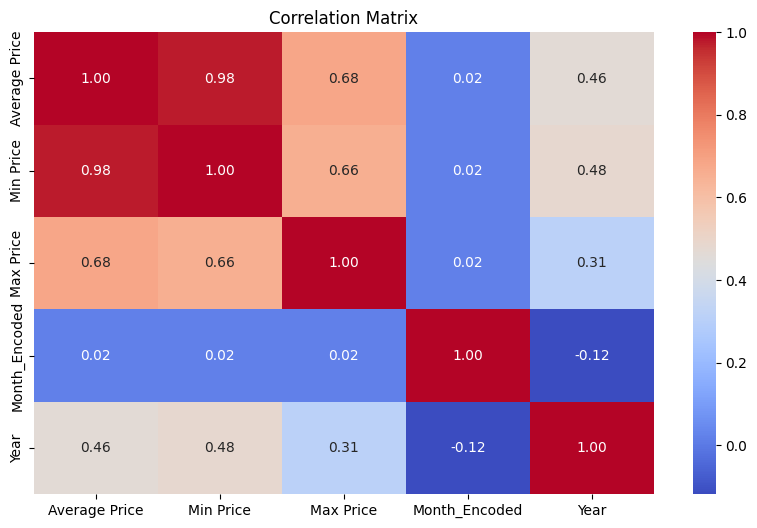

In [22]:
df['Month_Encoded'] = df['Month'].map({
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
})
# df['City_Encoded'] = df['City'].factorize()[0]
# df['Type_Encoded'] = df['Type'].factorize()[0]

# Select numerical columns for correlation analysis
numerical_cols = ['Average Price', 'Min Price', 'Max Price', 'Month_Encoded', 'Year']

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [23]:
df.drop(columns=['Price Range','City','Type'],inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1663544092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Price Range','City','Type'],inplace=True)


In [24]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded
54,Adibatla,3909.0,Oct-Dec,2024,2938.0,4880.0,4
55,Adibatla,4055.0,Jul-Sep,2024,3050.0,5060.0,3
56,Adibatla,3899.0,Apr-Jun,2024,2794.0,5004.0,2
57,Adibatla,3695.0,Jan-Mar,2024,2707.0,4683.0,1
58,Adibatla,3922.0,Oct-Dec,2023,2922.0,4921.0,4
...,...,...,...,...,...,...,...
4643,Yousufguda Main Road,7030.0,Jul-Sep,2019,5090.0,8760.0,3
4644,Yousufguda Main Road,7010.0,Apr-Jun,2019,5070.0,8730.0,2
4645,Yousufguda Main Road,6990.0,Jan-Mar,2019,5050.0,8700.0,1
4646,Yousufguda Main Road,6970.0,Oct-Dec,2018,5030.0,8670.0,4


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3643 entries, 54 to 4647
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Locality       3643 non-null   object 
 1   Average Price  3643 non-null   float64
 2   Month          3643 non-null   object 
 3   Year           3643 non-null   object 
 4   Min Price      3643 non-null   float64
 5   Max Price      3643 non-null   float64
 6   Month_Encoded  3643 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 227.7+ KB


In [26]:
df['Year'] = df['Year'].astype('float64')


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\2649418009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype('float64')


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3643 entries, 54 to 4647
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Locality       3643 non-null   object 
 1   Average Price  3643 non-null   float64
 2   Month          3643 non-null   object 
 3   Year           3643 non-null   float64
 4   Min Price      3643 non-null   float64
 5   Max Price      3643 non-null   float64
 6   Month_Encoded  3643 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 227.7+ KB


In [28]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded
54,Adibatla,3909.0,Oct-Dec,2024.0,2938.0,4880.0,4
55,Adibatla,4055.0,Jul-Sep,2024.0,3050.0,5060.0,3
56,Adibatla,3899.0,Apr-Jun,2024.0,2794.0,5004.0,2
57,Adibatla,3695.0,Jan-Mar,2024.0,2707.0,4683.0,1
58,Adibatla,3922.0,Oct-Dec,2023.0,2922.0,4921.0,4
...,...,...,...,...,...,...,...
4643,Yousufguda Main Road,7030.0,Jul-Sep,2019.0,5090.0,8760.0,3
4644,Yousufguda Main Road,7010.0,Apr-Jun,2019.0,5070.0,8730.0,2
4645,Yousufguda Main Road,6990.0,Jan-Mar,2019.0,5050.0,8700.0,1
4646,Yousufguda Main Road,6970.0,Oct-Dec,2018.0,5030.0,8670.0,4


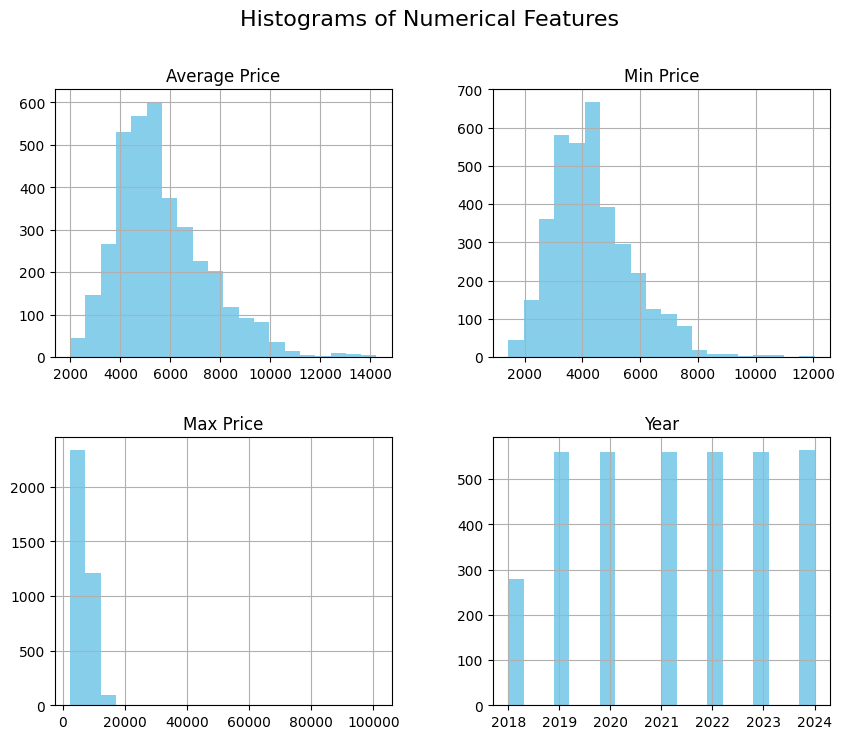

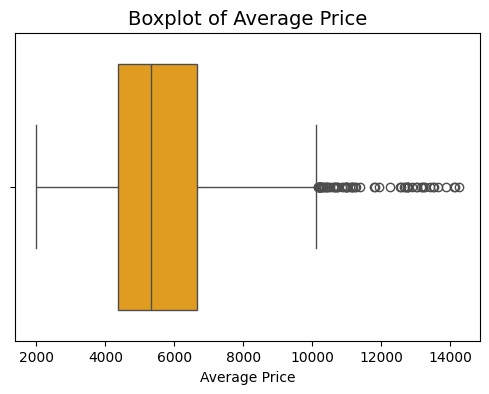

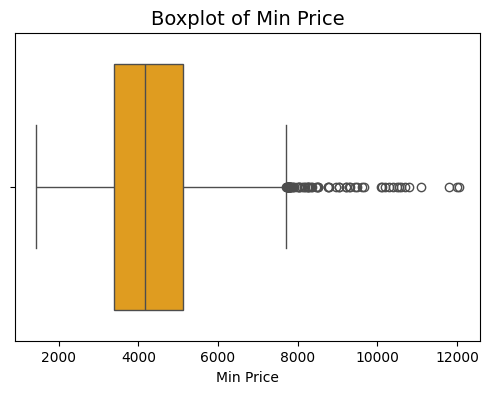

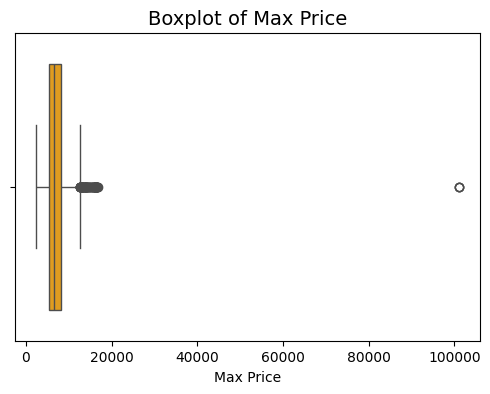

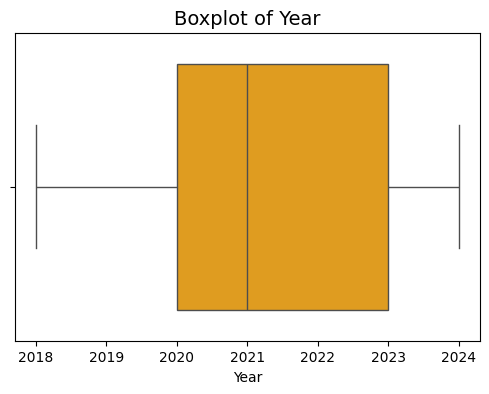

In [29]:
# Plot histograms for numerical columns
numerical_features = ['Average Price', 'Min Price', 'Max Price', 'Year']
df[numerical_features].hist(bins=20, figsize=(10, 8), color='skyblue')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()

# Box plots for numerical columns
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[feature], color='orange')
    plt.title(f'Boxplot of {feature}', fontsize=14)
    plt.show()


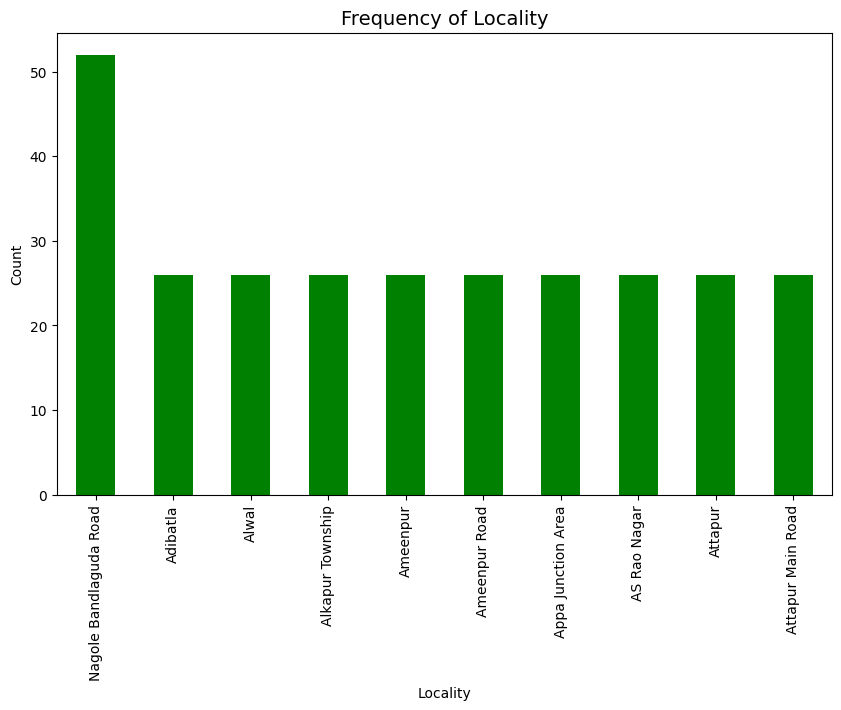

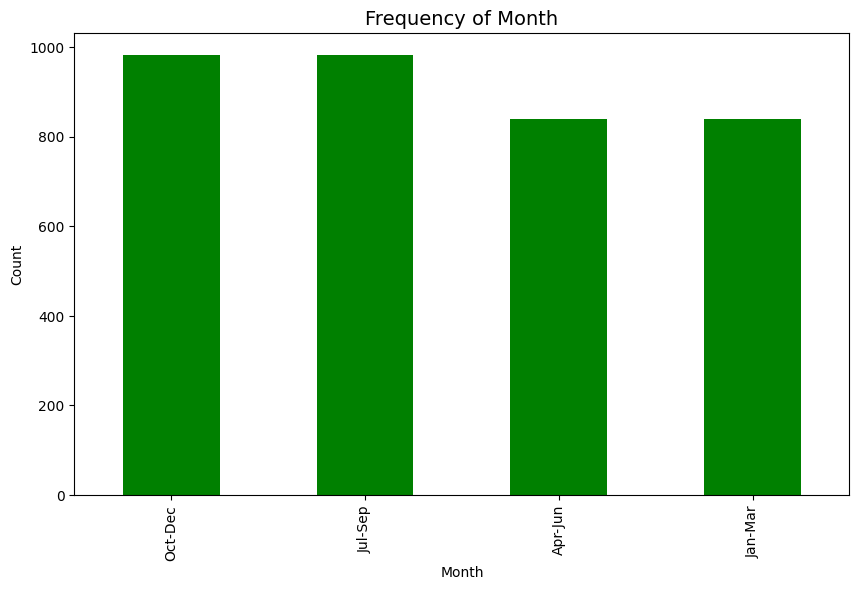

In [30]:
# Frequency tables and bar charts for categorical columns
categorical_features = ['Locality', 'Month']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    df[feature].value_counts().head(10).plot(kind='bar', color='green')
    plt.title(f'Frequency of {feature}', fontsize=14)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()


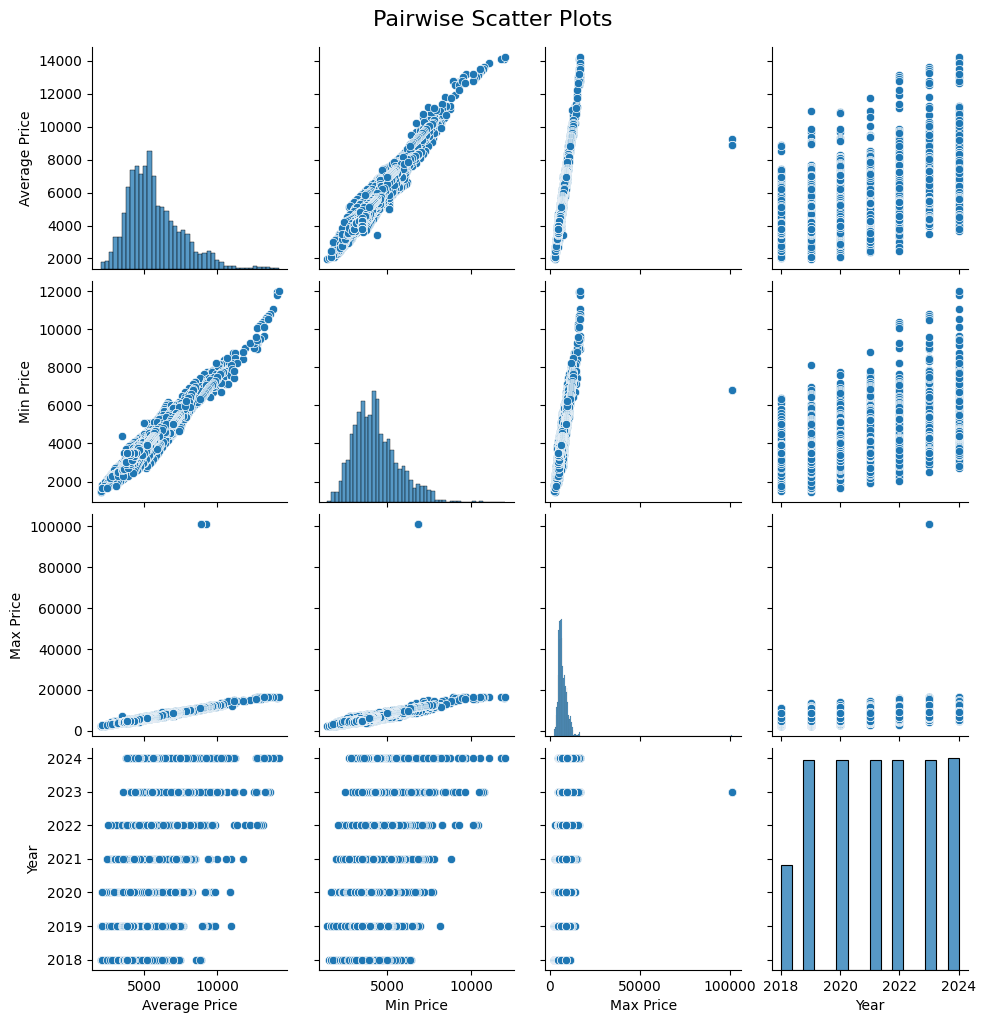

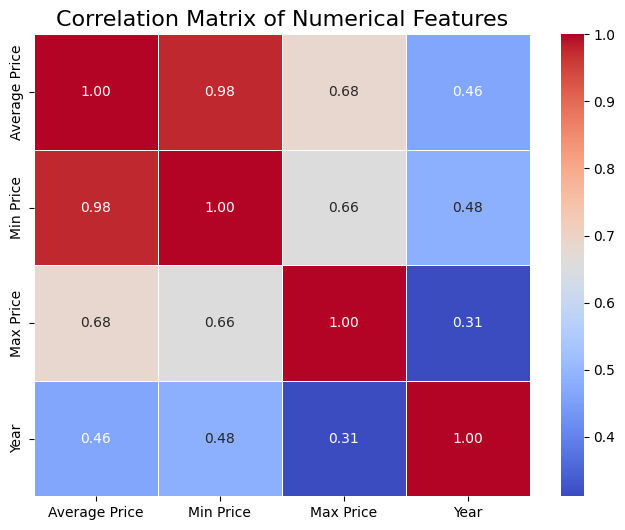

In [31]:
# Scatter plot to visualize relationships between numerical features
sns.pairplot(df[numerical_features])
plt.suptitle('Pairwise Scatter Plots', y=1.02, fontsize=16)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


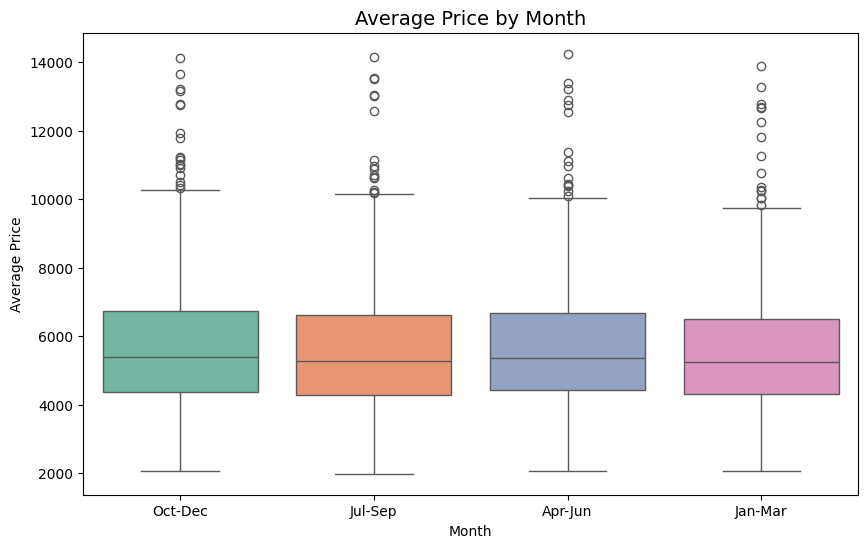

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


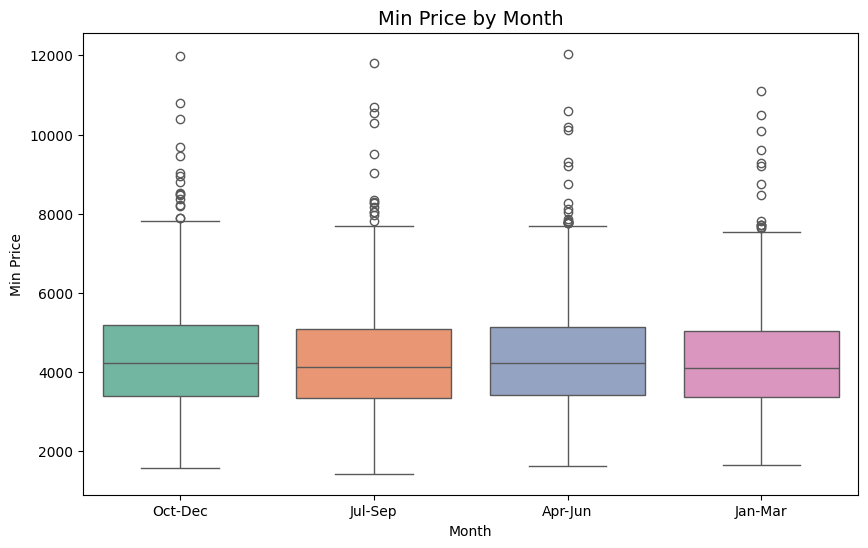

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


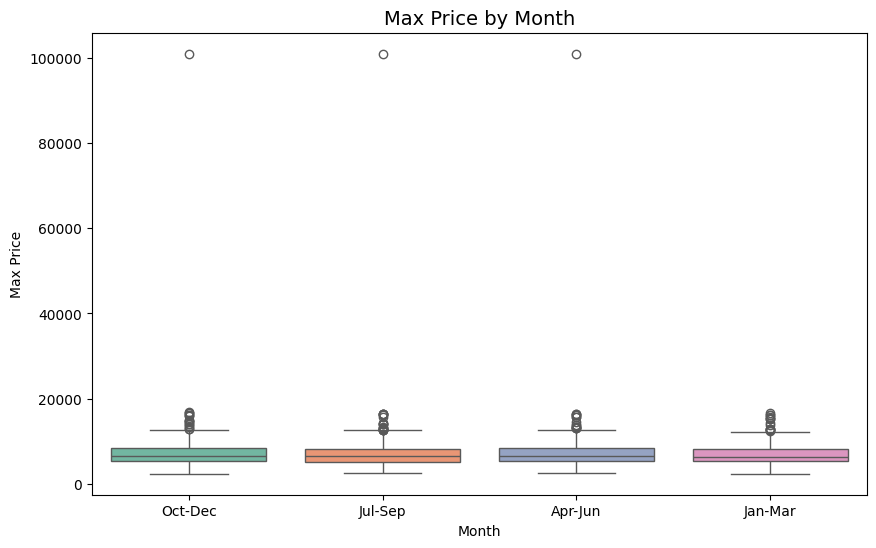

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


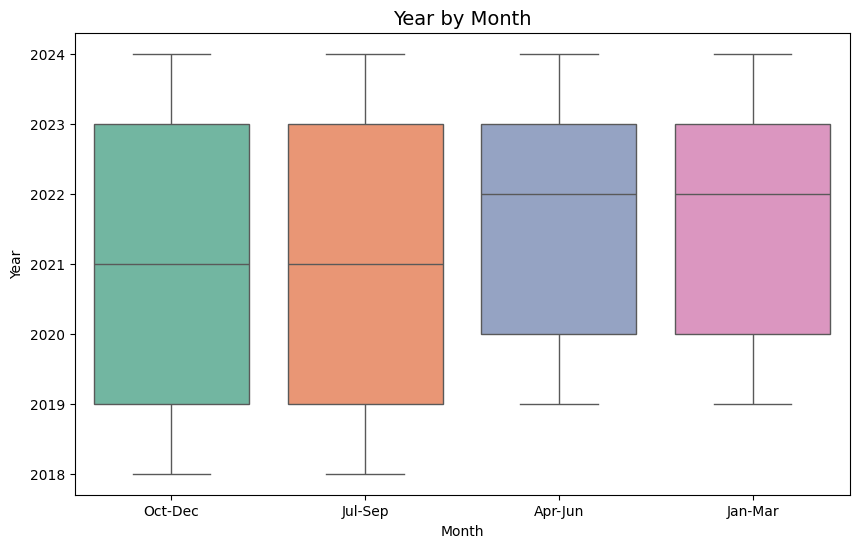

In [32]:
# Box plots to compare numerical features across categories
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Month', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Month', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel(feature)
    plt.show()


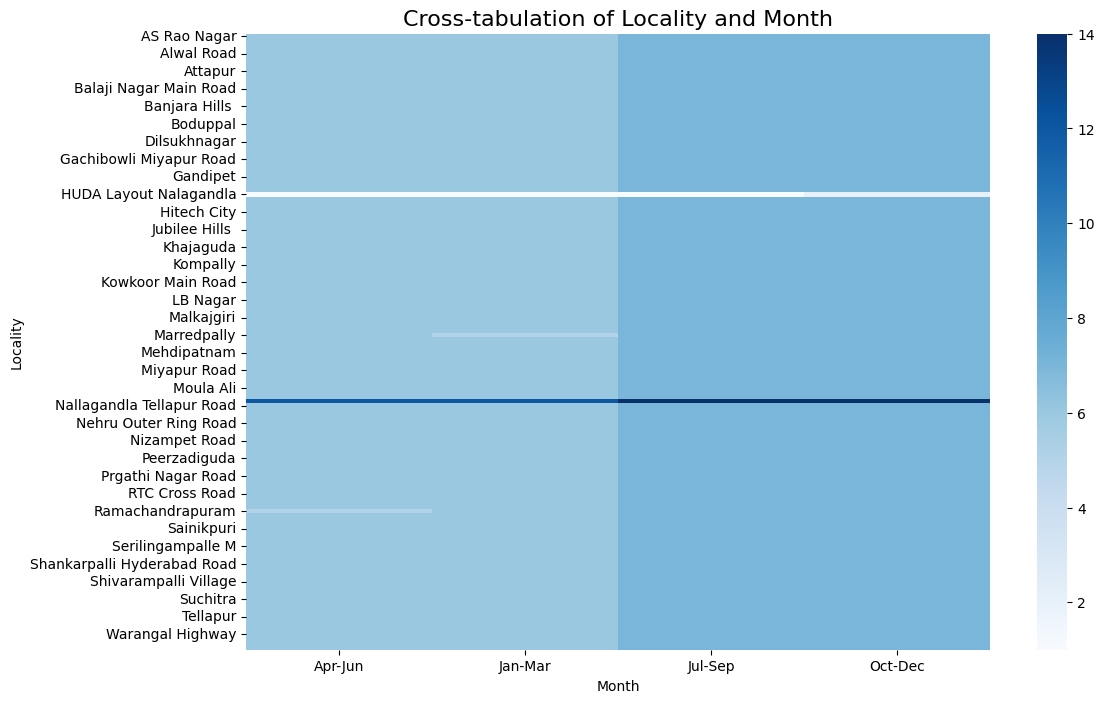

In [33]:
# Cross-tabulation and heatmap
cross_tab = pd.crosstab(df['Locality'], df['Month'])
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, cmap='Blues', annot=False, cbar=True)
plt.title('Cross-tabulation of Locality and Month', fontsize=16)
plt.show()


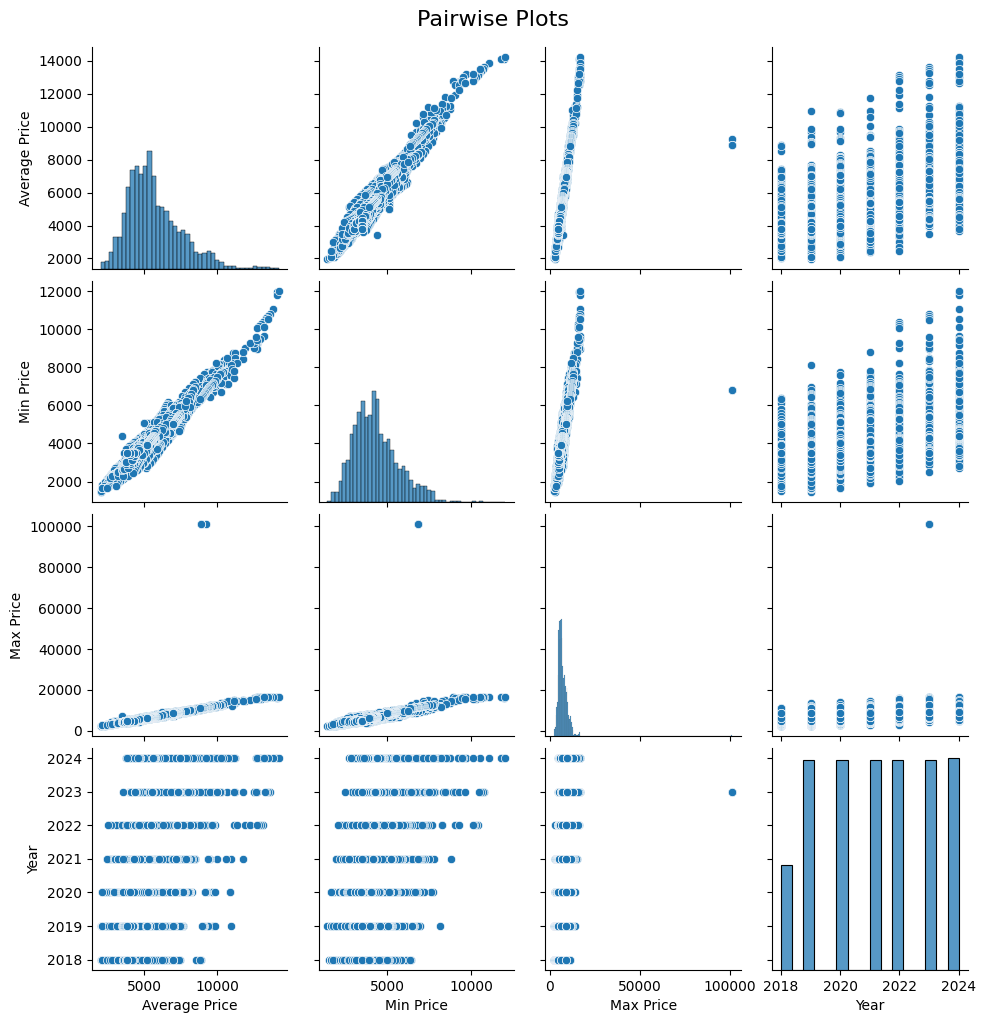

In [34]:
# Pair plot for selected features
selected_features = ['Average Price', 'Min Price', 'Max Price', 'Year']
sns.pairplot(df[selected_features])
plt.suptitle('Pairwise Plots', y=1.02, fontsize=16)
plt.show()


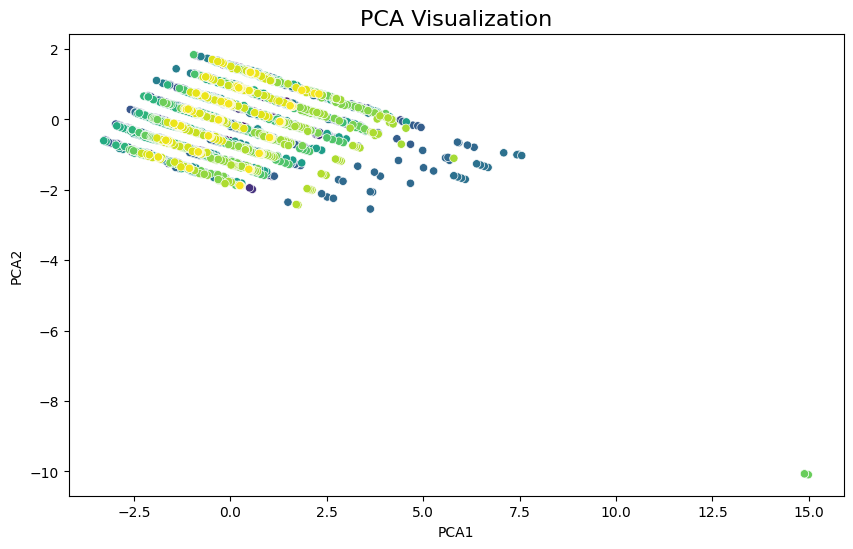

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df[numerical_features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(numerical_scaled)

pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['Locality'] = df['Locality']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Locality', data=pca_df, legend=False, palette='viridis')
plt.title('PCA Visualization', fontsize=16)
plt.show()


In [36]:
df = df.drop(df[df['Month'] == 'April-June'].index)

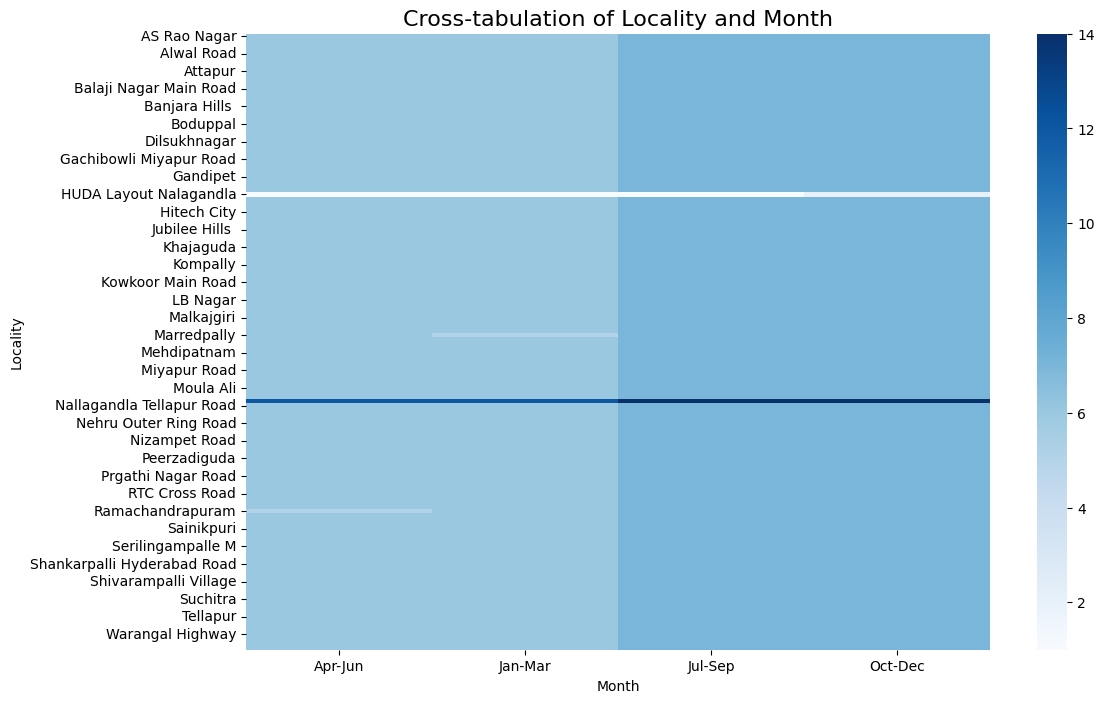

In [37]:
# Cross-tabulation and heatmap
cross_tab = pd.crosstab(df['Locality'], df['Month'])
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, cmap='Blues', annot=False, cbar=True)
plt.title('Cross-tabulation of Locality and Month', fontsize=16)
plt.show()

In [38]:
from sklearn.preprocessing import MinMaxScaler
columns_to_scale = ['Average Price', 'Min Price', 'Max Price']
scaler = MinMaxScaler(feature_range=(1, 10))
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
joblib.dump(scaler,'Hyderabad_price_scaling.pkl')

['Hyderabad_price_scaling.pkl']

In [39]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Locality'] = encoder.fit_transform(df['Locality'])
scaler = MinMaxScaler(feature_range=(1,10))
df[['Locality']] = scaler.fit_transform(df[['Locality']])
joblib.dump(encoder,'Hyderabad_locality_encoding.pkl')
joblib.dump(scaler,'Hyderabad_locality_scaling.pkl')


['Hyderabad_locality_scaling.pkl']

In [40]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded
54,1.064748,2.411117,Oct-Dec,2024.0,2.277594,1.230367,4
55,1.064748,2.518364,Jul-Sep,2024.0,2.372608,1.246789,3
56,1.064748,2.403771,Apr-Jun,2024.0,2.155434,1.241680,2
57,1.064748,2.253918,Jan-Mar,2024.0,2.081629,1.212394,1
58,1.064748,2.420666,Oct-Dec,2023.0,2.264021,1.234107,4
...,...,...,...,...,...,...,...
4643,10.000000,4.703722,Jul-Sep,2019.0,4.103214,1.584356,3
4644,10.000000,4.689030,Apr-Jun,2019.0,4.086248,1.581619,2
4645,10.000000,4.674339,Jan-Mar,2019.0,4.069281,1.578882,1
4646,10.000000,4.659647,Oct-Dec,2018.0,4.052314,1.576145,4


In [41]:
month_mapping = {
    "Jan-Mar": 1,
    "Apr-Jun": 2,
    "Jul-Sep": 3,
    "Oct-Dec": 4
}
df['Month_Mapped'] = df['Month'].map(month_mapping)

In [42]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded,Month_Mapped
54,1.064748,2.411117,Oct-Dec,2024.0,2.277594,1.230367,4,4
55,1.064748,2.518364,Jul-Sep,2024.0,2.372608,1.246789,3,3
56,1.064748,2.403771,Apr-Jun,2024.0,2.155434,1.241680,2,2
57,1.064748,2.253918,Jan-Mar,2024.0,2.081629,1.212394,1,1
58,1.064748,2.420666,Oct-Dec,2023.0,2.264021,1.234107,4,4
...,...,...,...,...,...,...,...,...
4643,10.000000,4.703722,Jul-Sep,2019.0,4.103214,1.584356,3,3
4644,10.000000,4.689030,Apr-Jun,2019.0,4.086248,1.581619,2,2
4645,10.000000,4.674339,Jan-Mar,2019.0,4.069281,1.578882,1,1
4646,10.000000,4.659647,Oct-Dec,2018.0,4.052314,1.576145,4,4


In [43]:
df.drop(columns=['Month'])

,Locality,Average Price,Year,Min Price,Max Price,Month_Encoded,Month_Mapped
54,1.064748,2.411117,2024.0,2.277594,1.230367,4,4
55,1.064748,2.518364,2024.0,2.372608,1.246789,3,3
56,1.064748,2.403771,2024.0,2.155434,1.241680,2,2
57,1.064748,2.253918,2024.0,2.081629,1.212394,1,1
58,1.064748,2.420666,2023.0,2.264021,1.234107,4,4
...,...,...,...,...,...,...,...
4643,10.000000,4.703722,2019.0,4.103214,1.584356,3,3
4644,10.000000,4.689030,2019.0,4.086248,1.581619,2,2
4645,10.000000,4.674339,2019.0,4.069281,1.578882,1,1
4646,10.000000,4.659647,2018.0,4.052314,1.576145,4,4


In [44]:
df['Year_sin'] = np.sin(2 * np.pi * (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min()))
df['Year_cos'] = np.cos(2 * np.pi * (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min()))


In [45]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded,Month_Mapped,Year_sin,Year_cos
54,1.064748,2.411117,Oct-Dec,2024.0,2.277594,1.230367,4,4,-2.449294e-16,1.0
55,1.064748,2.518364,Jul-Sep,2024.0,2.372608,1.246789,3,3,-2.449294e-16,1.0
56,1.064748,2.403771,Apr-Jun,2024.0,2.155434,1.241680,2,2,-2.449294e-16,1.0
57,1.064748,2.253918,Jan-Mar,2024.0,2.081629,1.212394,1,1,-2.449294e-16,1.0
58,1.064748,2.420666,Oct-Dec,2023.0,2.264021,1.234107,4,4,-8.660254e-01,0.5
...,...,...,...,...,...,...,...,...,...,...
4643,10.000000,4.703722,Jul-Sep,2019.0,4.103214,1.584356,3,3,8.660254e-01,0.5
4644,10.000000,4.689030,Apr-Jun,2019.0,4.086248,1.581619,2,2,8.660254e-01,0.5
4645,10.000000,4.674339,Jan-Mar,2019.0,4.069281,1.578882,1,1,8.660254e-01,0.5
4646,10.000000,4.659647,Oct-Dec,2018.0,4.052314,1.576145,4,4,0.000000e+00,1.0


In [46]:
df.drop(columns=['Year','Month','Month_Mapped'],inplace=True)

In [47]:
# df.drop(columns=['Month_Mapped'],inplace=True)

In [48]:
df

,Locality,Average Price,Min Price,Max Price,Month_Encoded,Year_sin,Year_cos
54,1.064748,2.411117,2.277594,1.230367,4,-2.449294e-16,1.0
55,1.064748,2.518364,2.372608,1.246789,3,-2.449294e-16,1.0
56,1.064748,2.403771,2.155434,1.241680,2,-2.449294e-16,1.0
57,1.064748,2.253918,2.081629,1.212394,1,-2.449294e-16,1.0
58,1.064748,2.420666,2.264021,1.234107,4,-8.660254e-01,0.5
...,...,...,...,...,...,...,...
4643,10.000000,4.703722,4.103214,1.584356,3,8.660254e-01,0.5
4644,10.000000,4.689030,4.086248,1.581619,2,8.660254e-01,0.5
4645,10.000000,4.674339,4.069281,1.578882,1,8.660254e-01,0.5
4646,10.000000,4.659647,4.052314,1.576145,4,0.000000e+00,1.0


In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos']
target = 'Average Price'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mape = (abs((y_test - y_pred) / y_test).mean()) * 100

print("Model Performance:") 
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

import joblib
joblib.dump(model, "Hyderabad_Prediction_Model.pkl")


Model Performance:
Mean Absolute Error (MAE): 0.3622690053634916
Mean Squared Error (MSE): 0.4249113629221877
R² Score: 0.7533047262896684
Mean Absolute Percentage Error (MAPE): 10.647391731425182%


['Hyderabad_Prediction_Model.pkl']

In [50]:
import pandas as pd
import numpy as np
import joblib

encoder = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_locality_encoding.pkl')
scaler = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_locality_scaling.pkl')
price_scaler = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_price_scaling.pkl')
month_mapping = {
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
}

def compute_year_sin_cos(year):
    base_year = 2019
    period = 6  
    year_index = year - base_year
    year_sin = np.sin(2 * np.pi * year_index / period)
    year_cos = np.cos(2 * np.pi * year_index / period)
    return year_sin, year_cos
def predict_price(location, year, quarter):
    location_encoded = encoder.transform([location])[0]
    location_scaled = scaler.transform([[location_encoded]])[0][0]  # Scaling after encoding

    month_encoded = month_mapping.get(quarter, None)
    if month_encoded is None:
        raise ValueError("Invalid quarter provided. Must be 'Jan-Mar', 'Apr-Jun', 'Jul-Sep', or 'Oct-Dec'.")

    year_sin, year_cos = compute_year_sin_cos(year)

    input_data = pd.DataFrame([[location_scaled, month_encoded, year_sin, year_cos]],
                              columns=['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos'])

    model = joblib.load("C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_Prediction_Model.pkl")

    predicted_price_scaled = model.predict(input_data)[0]

    temp_data = [[predicted_price_scaled, None, None]]  
    predicted_price = price_scaler.inverse_transform(temp_data)[0][0]

    return predicted_price

location = 'RTC Cross Road'
year = 2030
quarter = 'Jul-Sep'

predicted_price = predict_price(location, year, quarter)
print(f"Predicted Average Price for {location} in {quarter} {year}: ₹{predicted_price}")


Predicted Average Price for RTC Cross Road in Jul-Sep 2030: ₹6346.650000000005


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [51]:
import pandas as pd
import numpy as np
import joblib

encoder = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_locality_encoding.pkl')
scaler = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_locality_scaling.pkl')
price_scaler = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_price_scaling.pkl')

month_mapping = {
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
}

def compute_year_sin_cos(year):
    base_year = 2019
    period = 6  
    year_index = year - base_year
    year_sin = np.sin(2 * np.pi * year_index / period)
    year_cos = np.cos(2 * np.pi * year_index / period)
    return year_sin, year_cos

def predict_price(location, year, quarter, historical_data):
    # Encode and scale locality
    location_encoded = encoder.transform([location])[0]
    location_scaled = scaler.transform([[location_encoded]])[0][0]  # Scaling after encoding

    month_encoded = month_mapping.get(quarter, None)
    if month_encoded is None:
        raise ValueError("Invalid quarter provided. Must be 'Jan-Mar', 'Apr-Jun', 'Jul-Sep', or 'Oct-Dec'.")

    year_sin, year_cos = compute_year_sin_cos(year)

    input_data = pd.DataFrame([[location_scaled, month_encoded, year_sin, year_cos]],
                              columns=['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos'])

    model = joblib.load("C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_Prediction_Model.pkl")

    predicted_price_scaled = model.predict(input_data)[0]

    temp_data = [[predicted_price_scaled, None, None]]  
    predicted_price = price_scaler.inverse_transform(temp_data)[0][0]

    locality_data = historical_data[historical_data['Locality'] == location]
    if locality_data.empty:
        raise ValueError(f"No historical data available for {location}.")
 
    locality_data['Price Range'] = locality_data['Price Range'].str.replace(',', '', regex=False)
    locality_data[['Min Price', 'Max Price']] = locality_data['Price Range'].str.split('-', expand=True).astype(float)
    locality_data['Average Price'] = locality_data['Average Price'].str.replace(',', '', regex=False).astype(float)

    min_price_factor = locality_data['Min Price'].mean() / locality_data['Average Price'].mean()
    max_price_factor = locality_data['Max Price'].mean() / locality_data['Average Price'].mean()

    predicted_min_price = predicted_price * min_price_factor
    predicted_max_price = predicted_price * max_price_factor

    return predicted_price, predicted_min_price, predicted_max_price


location = 'RTC Cross Road'
year = 2026
quarter = 'Jan-Mar'

historical_data = pd.read_csv("c:\\Users\\Administrator\\Downloads\\Hyderabad Property Data(Sheet1).csv", encoding="ISO-8859-1")

predicted_price, predicted_min_price, predicted_max_price = predict_price(location, year, quarter, historical_data)

print(f"Predicted Average Price for {location} in {quarter} {year}: ₹{predicted_price:,.2f}")
print(f"Predicted Minimum Price for {location} in {quarter} {year}: ₹{predicted_min_price:,.2f}")
print(f"Predicted Maximum Price for {location} in {quarter} {year}: ₹{predicted_max_price:,.2f}")


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Average Price for RTC Cross Road in Jan-Mar 2026: ₹4,029.29
Predicted Minimum Price for RTC Cross Road in Jan-Mar 2026: ₹3,107.22
Predicted Maximum Price for RTC Cross Road in Jan-Mar 2026: ₹5,017.69


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1733551611.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locality_data['Price Range'] = locality_data['Price Range'].str.replace(',', '', regex=False)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1733551611.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locality_data[['Min Price', 'Max Price']] = locality_data['Price Range'].str.split('-', expand=True).astype(float)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19956\1